# BLOCK 1

In [42]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

# BLOCK 2

In [44]:
df = pd.read_excel('Telco_customer_churn.xlsx')
display(df.head())
display(df.info())

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

None

# BLOCK 3

## 1. We delete unnecessary columns

In [45]:
df = df.drop(columns=['Country', 'State', 'City', 'Latitude', 'Longitude', 'Lat Long', 'Zip Code','Churn Label', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
                      'Phone Service', 'Multiple Lines', 'Internet Service', 'Paperless Billing'])

## 2. Clean all column names at once

In [46]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,2,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,1,2,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,1,8,No,No,Yes,No,Yes,Yes,Month-to-month,Electronic check,99.65,820.5,1,86,5372,Moved
3,7892-POOKP,1,28,No,No,Yes,Yes,Yes,Yes,Month-to-month,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,1,49,No,Yes,Yes,No,Yes,Yes,Month-to-month,Bank transfer (automatic),103.70,5036.3,1,89,5340,Competitor had better devices


## 3. Looking for empty values

In [47]:
df.isna().sum()

customerid              0
count                   0
tenure_months           0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
contract                0
payment_method          0
monthly_charges         0
total_charges           0
churn_value             0
churn_score             0
cltv                    0
churn_reason         5174
dtype: int64

We check whether this is an error or a pattern.

In [48]:
df[(df['churn_reason'].isna()) & (df['churn_value'] != 0)].head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason


In [49]:
display(df[(df['churn_reason'].isna()) & (df['churn_value'] == 0)].head())

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason
1869,7590-VHVEG,1,1,No,Yes,No,No,No,No,Month-to-month,Electronic check,29.85,29.85,0,27,3964,NaN
1870,5575-GNVDE,1,34,Yes,No,Yes,No,No,No,One year,Mailed check,56.95,1889.5,0,61,3441,NaN
1871,7795-CFOCW,1,45,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic),42.30,1840.75,0,66,4307,NaN
1872,1452-KIOVK,1,22,No,Yes,No,No,Yes,No,Month-to-month,Credit card (automatic),89.10,1949.4,0,43,4459,NaN
1873,6713-OKOMC,1,10,Yes,No,No,No,No,No,Month-to-month,Mailed check,29.75,301.9,0,51,2013,NaN


We can understand that there are no comments because they are still using the link

In [50]:
df['churn_reason'] = df['churn_reason'].fillna("still using")

df.isna().sum()

customerid           0
count                0
tenure_months        0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
payment_method       0
monthly_charges      0
total_charges        0
churn_value          0
churn_score          0
cltv                 0
churn_reason         0
dtype: int64

In [51]:
df.groupby('churn_value')['churn_reason'].count()


churn_value
0    5174
1    1869
Name: churn_reason, dtype: int64

## 4. We are looking for other problems with the table.

In [52]:
display(df.describe())
df.info()

,count,tenure_months,monthly_charges,churn_value,churn_score,cltv
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,72.000000,118.750000,1.000000,100.000000,6500.000000


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   str    
 1   count              7043 non-null   int64  
 2   tenure_months      7043 non-null   int64  
 3   online_security    7043 non-null   str    
 4   online_backup      7043 non-null   str    
 5   device_protection  7043 non-null   str    
 6   tech_support       7043 non-null   str    
 7   streaming_tv       7043 non-null   str    
 8   streaming_movies   7043 non-null   str    
 9   contract           7043 non-null   str    
 10  payment_method     7043 non-null   str    
 11  monthly_charges    7043 non-null   float64
 12  total_charges      7043 non-null   object 
 13  churn_value        7043 non-null   int64  
 14  churn_score        7043 non-null   int64  
 15  cltv               7043 non-null   int64  
 16  churn_reason       7043 non-null   

In [53]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce').fillna(0)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   str    
 1   count              7043 non-null   int64  
 2   tenure_months      7043 non-null   int64  
 3   online_security    7043 non-null   str    
 4   online_backup      7043 non-null   str    
 5   device_protection  7043 non-null   str    
 6   tech_support       7043 non-null   str    
 7   streaming_tv       7043 non-null   str    
 8   streaming_movies   7043 non-null   str    
 9   contract           7043 non-null   str    
 10  payment_method     7043 non-null   str    
 11  monthly_charges    7043 non-null   float64
 12  total_charges      7043 non-null   float64
 13  churn_value        7043 non-null   int64  
 14  churn_score        7043 non-null   int64  
 15  cltv               7043 non-null   int64  
 16  churn_reason       7043 non-null   

In [54]:
df[df.duplicated()]

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason


We can begin to analyze the data on the issues

# BLOK 4: Answering questions

## 1. Is it true that the longer a client stays with us, the less likely they are to leave? What month/year in a client's life is the highest risk of losing them?

In [55]:
mon_contract = df[df['contract'] == 'Month-to-month']

granicy = [-1, 3, 12, 24, 36, 72]
name = ['0-3 month', '3-12 month', '> year', '> 2 year', '> 3 year']

mon_contract['tenure_time'] = pd.cut(mon_contract['tenure_months'], bins=granicy, labels=name)

mon_contract.head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason,tenure_time
0,3668-QPYBK,1,2,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer,0-3 month
1,9237-HQITU,1,2,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,1,67,2701,Moved,0-3 month
2,9305-CDSKC,1,8,No,No,Yes,No,Yes,Yes,Month-to-month,Electronic check,99.65,820.50,1,86,5372,Moved,3-12 month
3,7892-POOKP,1,28,No,No,Yes,Yes,Yes,Yes,Month-to-month,Electronic check,104.80,3046.05,1,84,5003,Moved,> 2 year
4,0280-XJGEX,1,49,No,Yes,Yes,No,Yes,Yes,Month-to-month,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices,> 3 year


In [56]:
time_analisys = mon_contract.groupby('tenure_time')['churn_value'].mean().reset_index()

display(time_analisys)

,tenure_time,churn_value
0,0-3 month,0.580488
1,3-12 month,0.442724
2,> year,0.377205
3,> 2 year,0.325103
4,> 3 year,0.296353


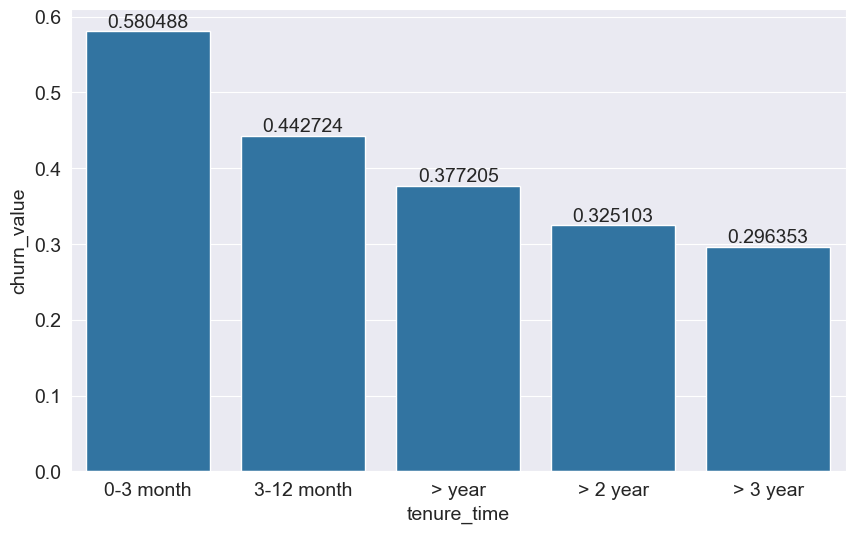

In [57]:
ax = sns.barplot(data=time_analisys, x='tenure_time', y='churn_value')
for container in ax.containers:
    ax.bar_label(container)

Customers leave the company in large numbers within the first year of use. Let's take a closer look below.

In [58]:
litle_mon_contract = mon_contract[mon_contract['tenure_months'] <= 12]

litle_mon_contract.describe()

,count,tenure_months,monthly_charges,total_charges,churn_value,churn_score,cltv
count,1994.0,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,1.0,4.474925,58.217904,276.693430,0.513541,66.333501,4043.561184
std,0.0,3.523503,25.996257,275.268999,0.499942,21.771071,1161.053255
min,1.0,1.000000,18.750000,18.850000,0.000000,20.000000,2003.000000
25%,1.0,1.000000,34.512500,70.012500,0.000000,51.000000,3034.000000
50%,1.0,3.000000,62.525000,168.150000,1.000000,71.000000,4094.500000
75%,1.0,7.000000,79.550000,418.375000,1.000000,83.000000,5056.750000
max,1.0,12.000000,112.950000,1384.750000,1.000000,100.000000,5998.000000


In [59]:
little_analisys = litle_mon_contract.groupby('tenure_months')['churn_value'].mean().reset_index()

display(little_analisys)

,tenure_months,churn_value
0,1,0.629139
1,2,0.526087
2,3,0.492147
3,4,0.496970
4,5,0.492188
5,6,0.421053
6,7,0.442478
7,8,0.405941
8,9,0.428571
9,10,0.468750


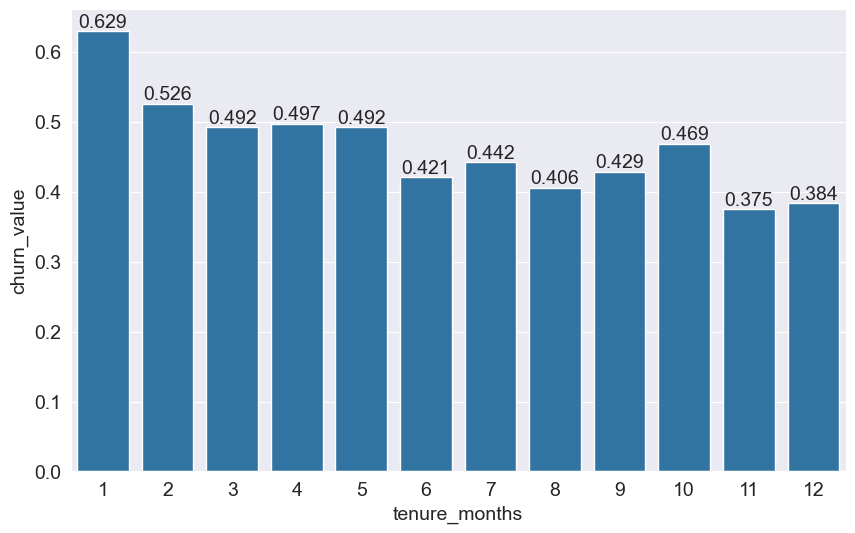

In [60]:
ax = sns.barplot(data=little_analisys, x='tenure_months', y='churn_value')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

380 people left the company in the first month and 121 in second.
### In conclusion:
1. Clients who use our company's services for more than a year are less likely to leave and stay with us.
2. The highest risk of losing a customer is in the first month, most likely due to the monthly service fee. For those with additional services like TV or movies, the bill typically exceeds $50.

## 2. How does contract type (monthly, annual, biennial) affect churn?

In [61]:
church_age = df.groupby('contract')['churn_value'].mean().reset_index()

display(church_age)

,contract,churn_value
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


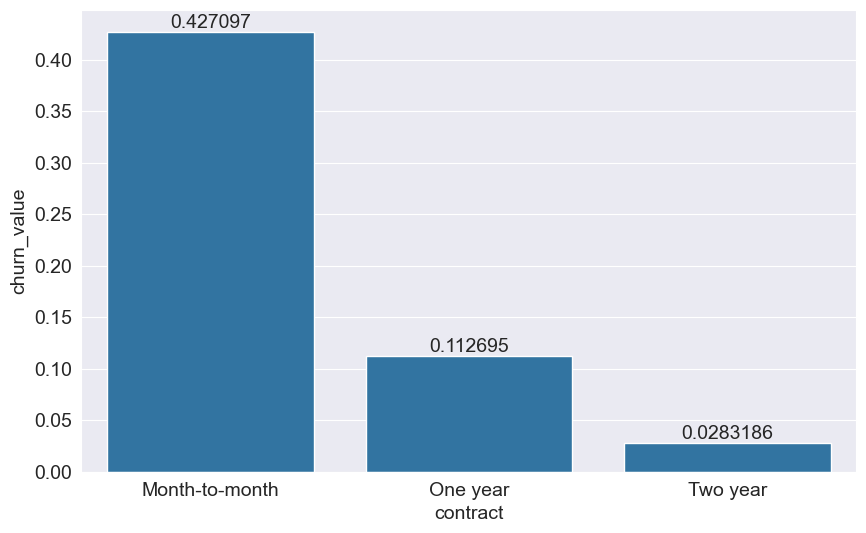

In [62]:
ax = sns.barplot(data=church_age, x='contract', y='churn_value')
for containers in ax.containers:
    ax.bar_label(containers)

Of course, clients who sign contracts for a year or two are already familiar with the company or trust us and leave less than a month.

## 3. We offer TechSupport and OnlineSecurity. Do they prevent churn, or do customers not care about these additional services?

In [63]:
df.head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason
0,3668-QPYBK,1,2,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer
1,9237-HQITU,1,2,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,1,67,2701,Moved
2,9305-CDSKC,1,8,No,No,Yes,No,Yes,Yes,Month-to-month,Electronic check,99.65,820.50,1,86,5372,Moved
3,7892-POOKP,1,28,No,No,Yes,Yes,Yes,Yes,Month-to-month,Electronic check,104.80,3046.05,1,84,5003,Moved
4,0280-XJGEX,1,49,No,Yes,Yes,No,Yes,Yes,Month-to-month,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices


In [64]:
df['online_security'] = df['online_security'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['online_backup'] = df['online_backup'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['device_protection'] = df['device_protection'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['tech_support'] = df['tech_support'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['streaming_tv'] = df['streaming_tv'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df['streaming_movies'] = df['streaming_movies'].map({'Yes': 1, 'No': 0, 'No internet service': 0})

df['additional_services'] = df['online_security'] + df['online_backup'] + df['device_protection'] + df['tech_support'] + df['streaming_tv'] + df['streaming_movies']

df.head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason,additional_services
0,3668-QPYBK,1,2,1,1,0,0,0,0,Month-to-month,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer,2
1,9237-HQITU,1,2,0,0,0,0,0,0,Month-to-month,Electronic check,70.70,151.65,1,67,2701,Moved,0
2,9305-CDSKC,1,8,0,0,1,0,1,1,Month-to-month,Electronic check,99.65,820.50,1,86,5372,Moved,3
3,7892-POOKP,1,28,0,0,1,1,1,1,Month-to-month,Electronic check,104.80,3046.05,1,84,5003,Moved,4
4,0280-XJGEX,1,49,0,1,1,0,1,1,Month-to-month,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices,4


In [65]:
df.describe()

,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,monthly_charges,total_charges,churn_value,churn_score,cltv,additional_services
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,32.371149,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,64.761692,2279.734304,0.265370,58.699418,4400.295755,2.037910
std,0.0,24.559481,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,30.090047,2266.794470,0.441561,21.525131,1183.057152,1.847682
min,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000,0.000000
25%,1.0,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,0.000000,40.000000,3469.000000,0.000000
50%,1.0,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000,2.000000
75%,1.0,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000,3.000000
max,1.0,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000,6.000000


In [66]:
table_services = df.groupby(['additional_services', 'contract'])['churn_value'].mean().reset_index()

display(table_services)

,additional_services,contract,churn_value
0,0,Month-to-month,0.383585
1,0,One year,0.031250
2,0,Two year,0.007800
3,1,Month-to-month,0.496009
4,1,One year,0.101449
5,1,Two year,0.000000
6,2,Month-to-month,0.447704
7,2,One year,0.082902
8,2,Two year,0.053571
9,3,Month-to-month,0.408293


(0.0, 0.7)

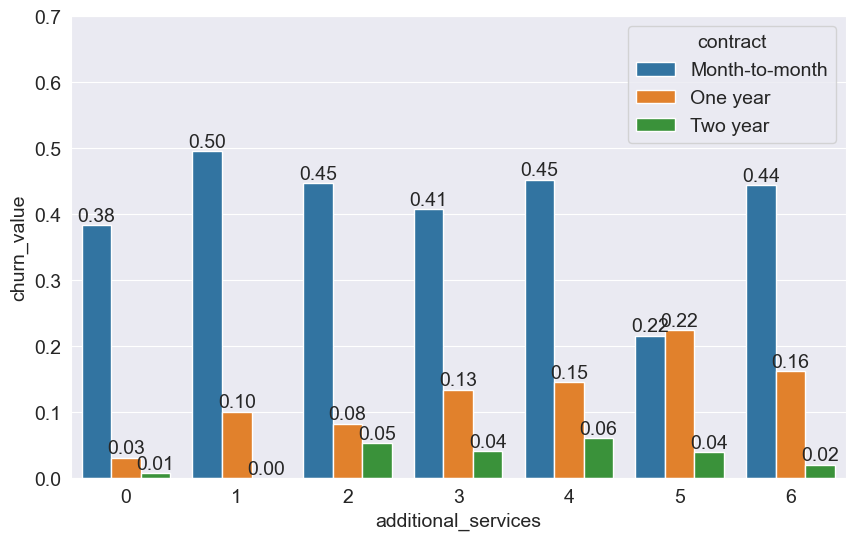

In [67]:
ax = sns.barplot(data=table_services, x='additional_services', y='churn_value', hue='contract')
for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f')
plt.ylim(0, 0.7)

## 4. Does the monthly payment size affect churn? Do those who pay the most (because it's expensive) or those on cheaper plans (because they're easily lured away with a discount) leave?

In [68]:
df['monthly_charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charges, dtype: float64

In [69]:
granicy = [18, 35, 89, 118]
name = ['cheap', 'medium', 'expensive']

df['monthly_charges_name'] = pd.cut(df['monthly_charges'], bins=granicy, labels=name)

df['monthly_charges_name'].value_counts()

monthly_charges_name
medium       3418
expensive    1884
cheap        1735
Name: count, dtype: int64

In [70]:
month_analysis = df.groupby('monthly_charges_name')['churn_value'].mean().reset_index()

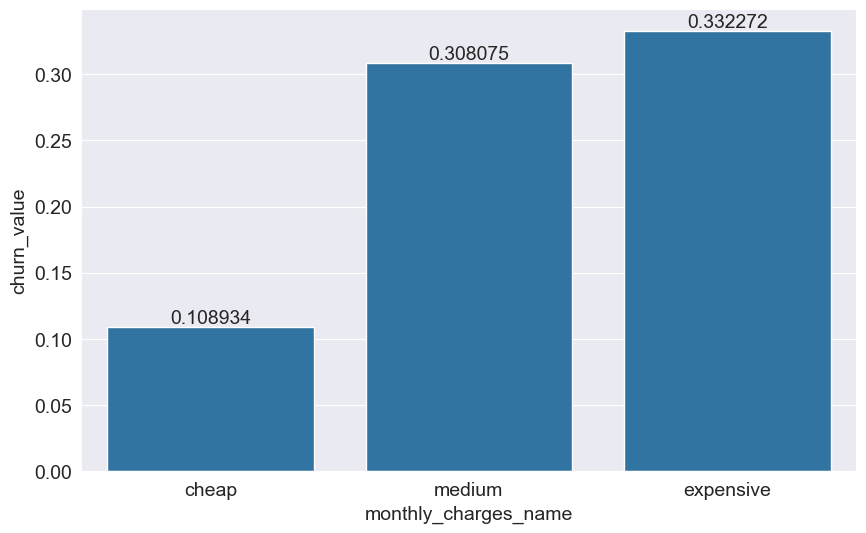

In [71]:
ax = sns.barplot(data=month_analysis, x='monthly_charges_name', y='churn_value')
for containers in ax.containers:
    ax.bar_label(containers)

In [72]:
df['tenure_months'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_months, dtype: float64

In [73]:
granicy = [-1, 3, 12, 24, 36, 72]
name = ['0-3 month', '3-12 month', '> year', '> 2 year', '> 3 year']

df['tenure_time'] = pd.cut(df['tenure_months'], bins=granicy, labels=name)

df.head()

,customerid,count,tenure_months,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,payment_method,monthly_charges,total_charges,churn_value,churn_score,cltv,churn_reason,additional_services,monthly_charges_name,tenure_time
0,3668-QPYBK,1,2,1,1,0,0,0,0,Month-to-month,Mailed check,53.85,108.15,1,86,3239,Competitor made better offer,2,medium,0-3 month
1,9237-HQITU,1,2,0,0,0,0,0,0,Month-to-month,Electronic check,70.70,151.65,1,67,2701,Moved,0,medium,0-3 month
2,9305-CDSKC,1,8,0,0,1,0,1,1,Month-to-month,Electronic check,99.65,820.50,1,86,5372,Moved,3,expensive,3-12 month
3,7892-POOKP,1,28,0,0,1,1,1,1,Month-to-month,Electronic check,104.80,3046.05,1,84,5003,Moved,4,expensive,> 2 year
4,0280-XJGEX,1,49,0,1,1,0,1,1,Month-to-month,Bank transfer (automatic),103.70,5036.30,1,89,5340,Competitor had better devices,4,expensive,> 3 year


In [74]:
month_analysis = df.groupby(['monthly_charges_name', 'tenure_time'])['churn_value'].mean().reset_index()
month_analysis

,monthly_charges_name,tenure_time,churn_value
0,cheap,0-3 month,0.332326
1,cheap,3-12 month,0.135484
2,cheap,> year,0.055351
3,cheap,> 2 year,0.047368
4,cheap,> 3 year,0.020537
5,medium,0-3 month,0.655332
6,medium,3-12 month,0.421462
7,medium,> year,0.300935
8,medium,> 2 year,0.199029
9,medium,> 3 year,0.097375


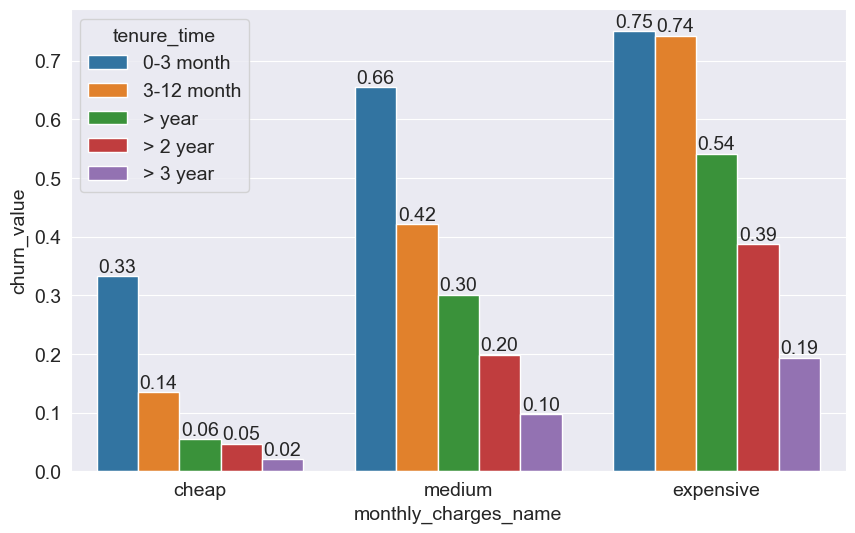

In [75]:
ax = sns.barplot(data=month_analysis, x='monthly_charges_name', y='churn_value', hue='tenure_time')
for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f')